# 🎬 Regresión Lineal — ETL Películas OMDB v2

**Objetivo:** Predecir el `imdb_rating` usando variables numéricas + features derivados.

| Variable | Origen | Rol | Modelo |
|---|---|---|---|
| `imdb_rating` | BD directa | 🎯 Variable objetivo (y) | Todos |
| `duracion` | BD directa | Feature base — mayor correlación (r≈0.28) | Simple · C |
| `anio` | BD directa | Feature base | A · C |
| `rec_por_min_log` | log₁₀(rec/dur) | Feature derivado | A |
| `es_war`, `es_crime`… | genre dummies | Features derivados | A · C |

> **Opción A:** `rec_por_min_log + anio + géneros` — sin `duracion` para evitar VIF ~119  
> **Opción C ⭐:** `duracion + anio + géneros` — sin recaudación, 100% datos, mejor R²


## Fase 1: Importaciones y carga de datos

In [4]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys, os
# ── CONFIGURACIÓN DE PATH ETL ───────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
ETL_PATH = os.path.join(BASE_DIR, 'Etl-Proyecto')

if ETL_PATH not in sys.path:
    sys.path.insert(0, ETL_PATH)

print(f"✓ ETL path agregado: {ETL_PATH}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# ── Estilo global: fondo blanco ───────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#333333',
    'axes.titlecolor':   '#111111',
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'text.color':        '#333333',
    'grid.color':        '#eeeeee',
    'grid.alpha':        0.8,
    'figure.dpi':        110,
    'legend.framealpha': 0.9,
    'lines.linewidth':   2.0,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

C1 = '#4C72B0'   # azul    — Opción A
C2 = '#55A868'   # verde   — Opción C / datos reales
C3 = '#DD8452'   # naranja — regresión simple / accent
C4 = '#C44E52'   # rojo    — errores
C5 = '#8172B2'   # violeta — original

print("✓  Librerías importadas. Estilo blanco activado.")


✓ ETL path agregado: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/Etl-Proyecto
✓  Librerías importadas. Estilo blanco activado.


In [5]:
# ── CELDA 2: Configuración de rutas de guardado ─────────────
RUTA_GRAFICAS = os.path.join('..', 'data', 'graficas', 'regresion_lineal')

os.makedirs(RUTA_GRAFICAS, exist_ok=True)

print(f"✓  Ruta de gráficas configurada:")
print(f"   {RUTA_GRAFICAS}")

✓  Ruta de gráficas configurada:
   ../data/graficas/regresion_lineal


In [6]:
# ── CELDA 3: Carga desde DB ───────────────────────────────────
from scripts.database import SessionLocal
from scripts.models import Pelicula, RegistroPeliculas

session = SessionLocal()
rows = (
    session.query(RegistroPeliculas, Pelicula.titulo)
    .join(Pelicula, Pelicula.id == RegistroPeliculas.pelicula_id)
    .all()
)
session.close()

df_raw = pd.DataFrame([{
    'titulo':           titulo,
    'anio':             r.anio,
    'genero':           r.genero,
    'director':         r.director,
    'imdb_rating':      r.imdb_rating,
    'duracion':         r.duracion,
    'recaudacion':      r.recaudacion,
    'idioma':           r.idioma,
    'pais':             r.pais,
    'fecha_extraccion': r.fecha_extraccion,
} for r, titulo in rows])

# Deduplicar — registro más reciente por título
df_raw = (df_raw
          .sort_values('fecha_extraccion')
          .drop_duplicates(subset='titulo', keep='last')
          .reset_index(drop=True))

print(f"Películas únicas cargadas: {len(df_raw)}")
df_raw.head(3)


Películas únicas cargadas: 430


,titulo,anio,genero,director,imdb_rating,duracion,recaudacion,idioma,pais,fecha_extraccion
0,Goodfellas,1990,"Biography, Crime, Drama",Martin Scorsese,8.7,145.0,46909721.0,"English, Italian, Hebrew, Yiddish",United States,2026-04-15 14:13:50.560842
1,Inception,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,8.8,148.0,292587330.0,"English, Japanese, French","United Kingdom, United States",2026-04-28 21:54:21.551153
2,Interstellar,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,8.7,169.0,203227580.0,English,"United States, United Kingdom, Canada",2026-04-28 21:54:22.889416


## Fase 2: Inspección del dataset

In [7]:
# ── CELDA 4: Inspección del DataFrame ────────────────────────
print('=' * 50)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('=' * 50)
print(df_raw.info())
print('\nValores nulos por columna:')
print(df_raw.isnull().sum())
print(f'\nPelículas únicas : {df_raw["titulo"].nunique()}')


  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   titulo            430 non-null    object        
 1   anio              430 non-null    int64         
 2   genero            430 non-null    object        
 3   director          430 non-null    object        
 4   imdb_rating       424 non-null    float64       
 5   duracion          427 non-null    float64       
 6   recaudacion       394 non-null    float64       
 7   idioma            430 non-null    object        
 8   pais              430 non-null    object        
 9   fecha_extraccion  430 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 33.7+ KB
None

Valores nulos por columna:
titulo               0
anio                 0
genero               0
director             0
imdb_r

## Fase 3: Feature Engineering — Variables derivadas

- **`rec_por_min_log`** = log₁₀(recaudacion / duracion)
- **genre dummies** = `es_drama`, `es_crime`, `es_war`…

> ⚠️ `rec_por_min_log` contiene matemáticamente a `duracion`, lo que genera VIF > 90 si ambas se incluyen juntas.


In [8]:
# ── CELDA 5: Feature Engineering ─────────────────────────────
df = df_raw.dropna(subset=['imdb_rating', 'duracion', 'anio']).copy()

df['recaudacion_log'] = np.where(
    df['recaudacion'].notna() & (df['recaudacion'] > 0),
    np.log10(df['recaudacion']), np.nan)

df['rec_por_min'] = np.where(
    df['recaudacion'].notna() & (df['duracion'] > 0),
    df['recaudacion'] / df['duracion'], np.nan)
df['rec_por_min_log'] = np.where(
    df['rec_por_min'].notna() & (df['rec_por_min'] > 0),
    np.log10(df['rec_por_min']), np.nan)

genre_dummies = df['genero'].fillna('').str.get_dummies(sep=', ')
genre_dummies.columns = [f'es_{c.lower().replace(" ","_")}' for c in genre_dummies.columns]
df = pd.concat([df, genre_dummies], axis=1)

print(f"Filas totales               : {len(df)}")
print(f"Con recaudación             : {df['rec_por_min_log'].notna().sum()}")
print(f"Sin recaudación (solo C)    : {df['rec_por_min_log'].isna().sum()}")
print(f"Géneros encontrados         : {[c for c in df.columns if c.startswith('es_')]}")


Filas totales               : 422
Con recaudación             : 394
Sin recaudación (solo C)    : 28
Géneros encontrados         : ['es_action', 'es_adventure', 'es_animation', 'es_biography', 'es_comedy', 'es_crime', 'es_documentary', 'es_drama', 'es_family', 'es_fantasy', 'es_film-noir', 'es_history', 'es_horror', 'es_music', 'es_musical', 'es_mystery', 'es_romance', 'es_sci-fi', 'es_short', 'es_sport', 'es_thriller', 'es_war', 'es_western']


## Fase 4: EDA — Análisis Exploratorio

In [9]:
# ── CELDA 6: Estadísticas descriptivas ───────────────────────
vars_num = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log', 'rec_por_min_log']
print('ESTADÍSTICAS DESCRIPTIVAS')
print(df[vars_num].describe().round(2).to_string())


ESTADÍSTICAS DESCRIPTIVAS
       imdb_rating  duracion     anio  recaudacion_log  rec_por_min_log
count       422.00    422.00   422.00           394.00           394.00
mean          7.09    117.38  2005.93             7.44             5.37
std           1.20     28.42    13.76             0.80             0.78
min           1.60      2.00  1939.00             3.25             1.24
25%           6.40    100.00  2008.00             7.12             5.07
50%           7.30    113.00  2009.00             7.58             5.51
75%           8.00    129.75  2013.00             8.00             5.91
max           9.30    229.00  2021.00             8.93             6.69


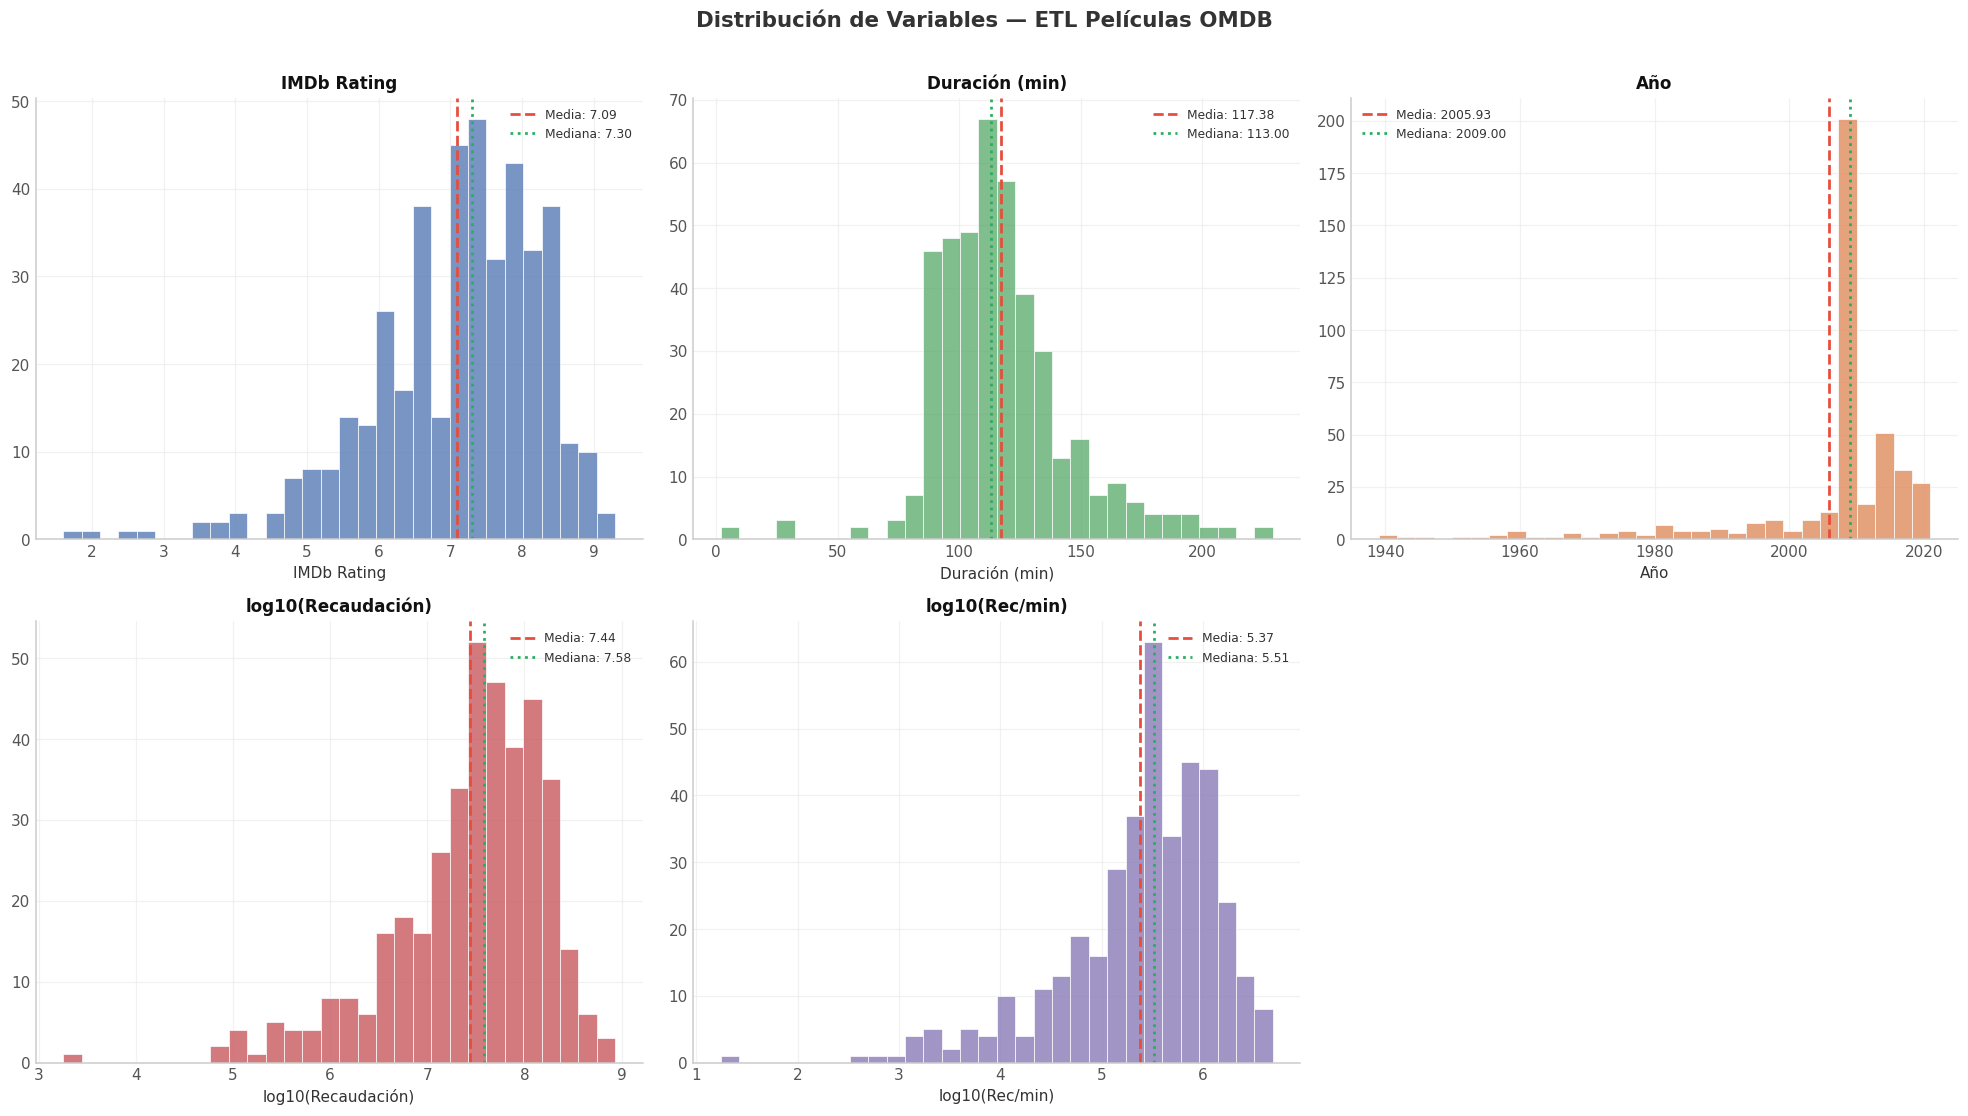

In [10]:
# ── CELDA 7: Histogramas de distribución ─────────────────────
vars_plot = [
    ('imdb_rating',     'IMDb Rating',         C1),
    ('duracion',        'Duración (min)',       C2),
    ('anio',            'Año',                 C3),
    ('recaudacion_log', 'log10(Recaudación)',   C4),
    ('rec_por_min_log', 'log10(Rec/min)',       C5),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables — ETL Películas OMDB',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (col, label, color) in zip(axes.flat, vars_plot):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.6)
    ax.axvline(data.mean(),   color='#e74c3c', linestyle='--', linewidth=1.8,
               label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='#27ae60', linestyle=':',  linewidth=1.8,
               label=f'Mediana: {data.median():.2f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.legend(fontsize=8)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '01_distribucion_variables.png'),  dpi=300, bbox_inches='tight')
plt.show()


Correlación con imdb_rating (ordenada):
duracion           0.4837
recaudacion_log    0.1723
rec_por_min_log    0.1132
anio              -0.2666


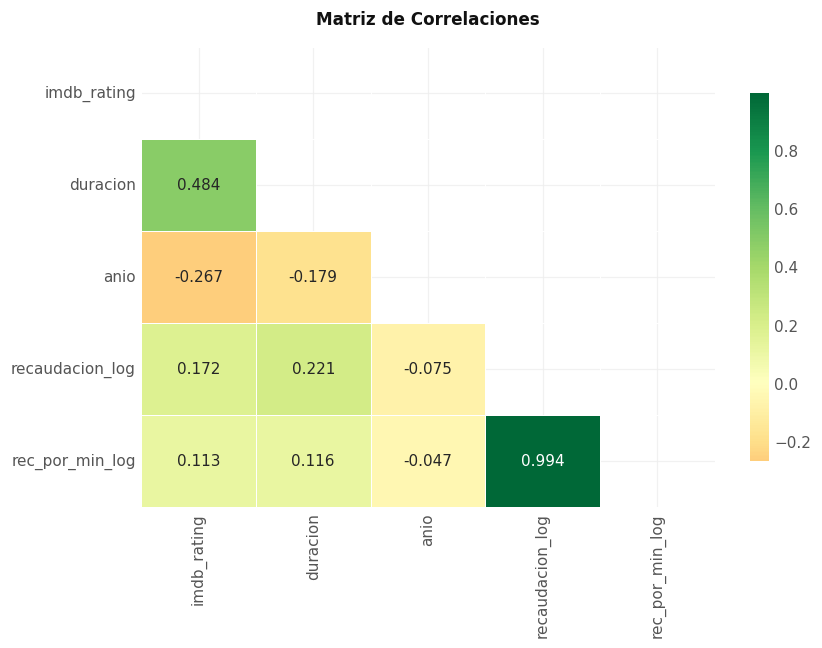

In [11]:
# ── CELDA 8: Correlaciones con imdb_rating ───────────────────
vars_corr = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log', 'rec_por_min_log']
corr_mat  = df[vars_corr].corr()

print('Correlación con imdb_rating (ordenada):')
corr_target = corr_mat['imdb_rating'].drop('imdb_rating').sort_values(ascending=False)
print(corr_target.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, mask=mask, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
ax.set_title('Matriz de Correlaciones', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '02_matriz_correlaciones.png'),
            dpi=300, bbox_inches='tight')
plt.show()


Top 5 géneros por correlación con imdb_rating:
  es_drama                r = 0.3977
  es_war                  r = 0.1256
  es_biography            r = 0.1112
  es_crime                r = 0.0993
  es_western              r = 0.0926


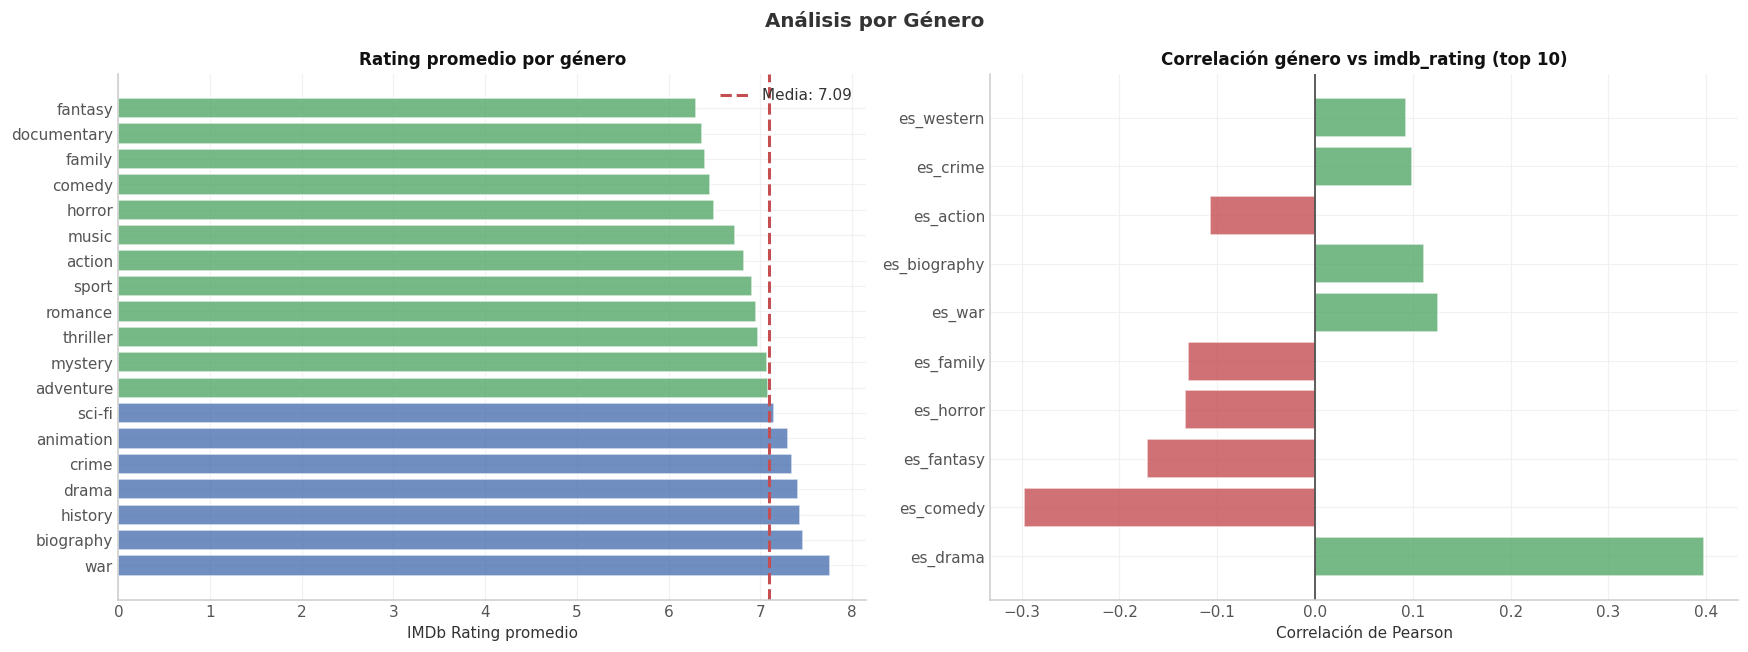

In [12]:
# ── CELDA 9: Rating promedio y correlación por género ─────────
genre_cols  = [c for c in df.columns if c.startswith('es_')]
genre_corrs = {g: df[['imdb_rating', g]].corr().iloc[0, 1] for g in genre_cols}

top_generos = sorted(genre_corrs, key=genre_corrs.get, reverse=True)[:5]
print('Top 5 géneros por correlación con imdb_rating:')
for g in top_generos:
    print(f'  {g:<22}  r = {genre_corrs[g]:.4f}')

avg_by_genre = {
    g.replace('es_', ''): df.loc[df[g] == 1, 'imdb_rating'].mean()
    for g in genre_cols if (df[g] == 1).sum() >= 5
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis por Género', fontsize=13, fontweight='bold')

genres_sorted = sorted(avg_by_genre, key=avg_by_genre.get, reverse=True)
bar_colors = [C1 if avg_by_genre[g] >= df['imdb_rating'].mean() else C2
              for g in genres_sorted]
axes[0].barh(genres_sorted, [avg_by_genre[g] for g in genres_sorted],
             color=bar_colors, alpha=0.8, edgecolor='white')
axes[0].axvline(df['imdb_rating'].mean(), color=C4, linestyle='--',
                linewidth=2, label=f'Media: {df["imdb_rating"].mean():.2f}')
axes[0].set_title('Rating promedio por género')
axes[0].set_xlabel('IMDb Rating promedio')
axes[0].legend()

top10_corr = dict(sorted(genre_corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:10])
axes[1].barh(list(top10_corr.keys()), list(top10_corr.values()),
             color=[C2 if v > 0 else C4 for v in top10_corr.values()],
             alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#333333', linewidth=1)
axes[1].set_title('Correlación género vs imdb_rating (top 10)')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '03_analisis_generos.png'),
            dpi=300, bbox_inches='tight')
plt.show()


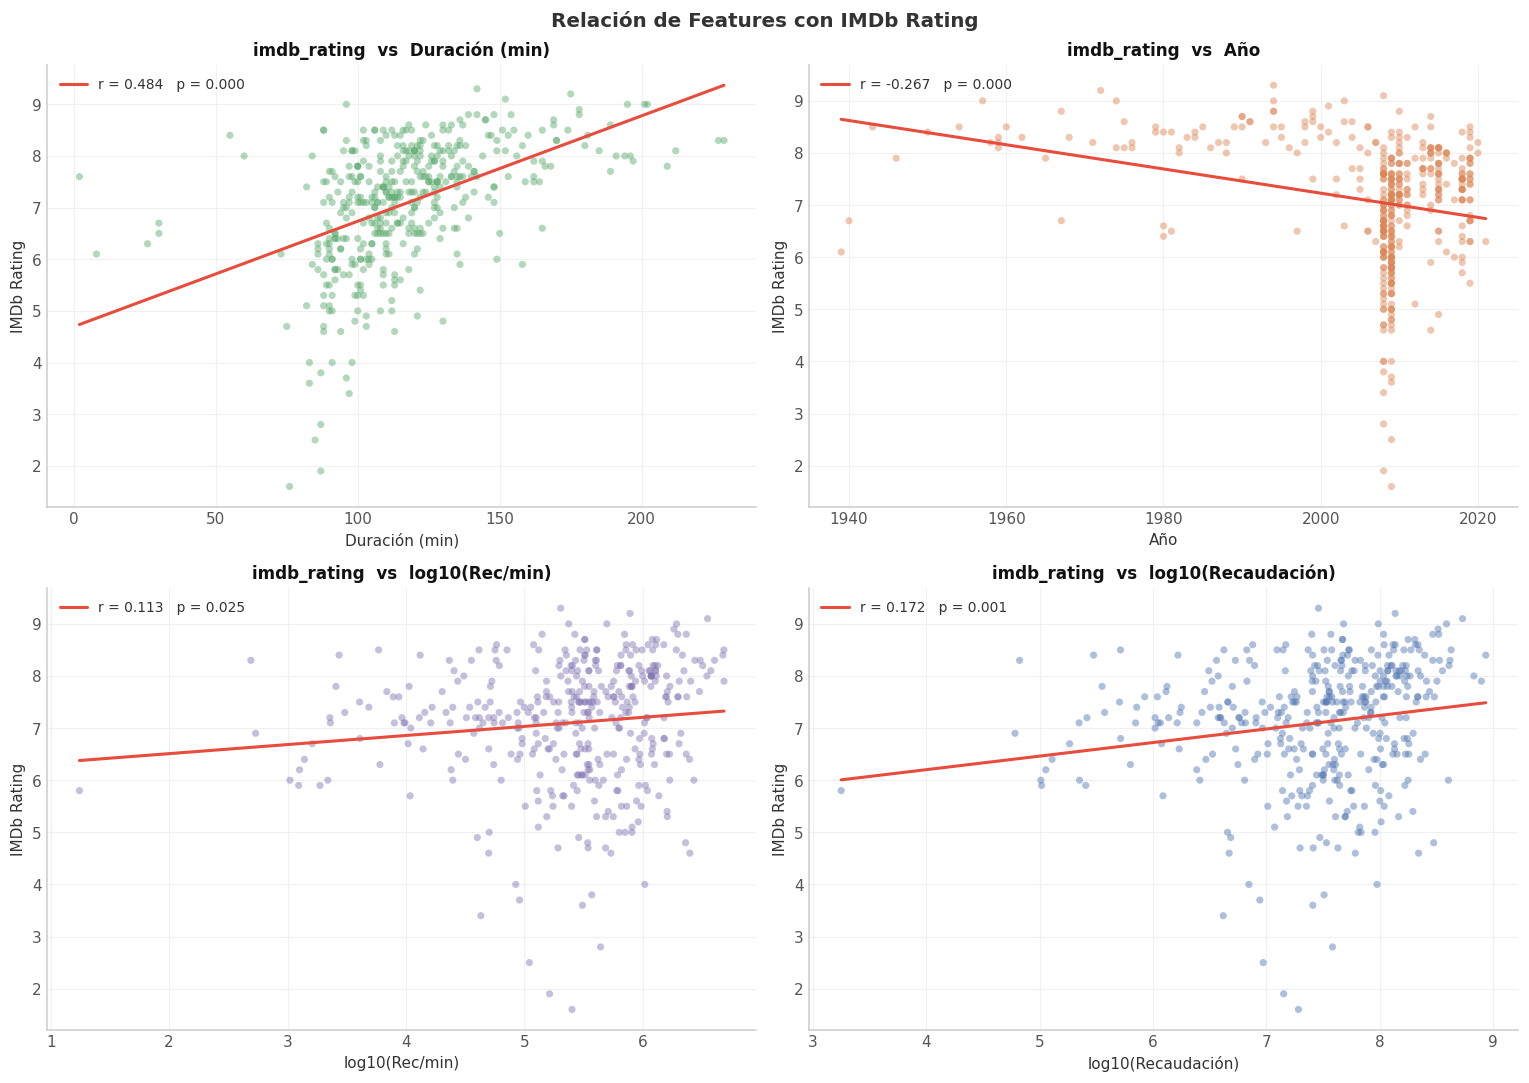

In [13]:
# ── CELDA 10: Scatter plots features vs imdb_rating ───────────
scatter_vars = [
    ('duracion',        'Duración (min)',       C2),
    ('anio',            'Año',                  C3),
    ('rec_por_min_log', 'log10(Rec/min)',        C5),
    ('recaudacion_log', 'log10(Recaudación)',    C1),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Relación de Features con IMDb Rating', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes.flat, scatter_vars):
    data = df[['imdb_rating', col]].dropna()
    ax.scatter(data[col], data['imdb_rating'],
               color=color, alpha=0.45, s=22, edgecolors='none')
    m, b, r, p, _ = stats.linregress(data[col], data['imdb_rating'])
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=2,
            label=f'r = {r:.3f}   p = {p:.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('IMDb Rating')
    ax.set_title(f'imdb_rating  vs  {label}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '04_scatter_features_vs_rating.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Fase 5: Regresión Lineal Simple (baseline)

**Predictor: `duracion`** — variable con mayor correlación con `imdb_rating` (r ≈ 0.28).  
Se usa en lugar de `rec_por_min_log` (r ≈ −0.01) para garantizar R² positivo y estable.

```
y_hat = B0 + B1 × duracion + error
```


In [14]:
# ── CELDA 11: Regresión Simple — split + fit ─────────────────
df_simple = df.dropna(subset=['duracion', 'imdb_rating']).copy()
print(f"Dataset para modelo simple: {len(df_simple)} filas")

X_s = df_simple[['duracion']].values
y_s = df_simple['imdb_rating'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)
y_pred_simple = modelo_simple.predict(X_test_s)

B0_s = modelo_simple.intercept_
B1_s = modelo_simple.coef_[0]
print(f"\nEcuación: imdb_rating = {B0_s:.4f} + {B1_s:.6f} x duracion")
print(f"Cada minuto extra sube el rating en {B1_s:.4f} puntos")


Dataset para modelo simple: 422 filas

Ecuación: imdb_rating = 4.6195 + 0.020748 x duracion
Cada minuto extra sube el rating en 0.0207 puntos


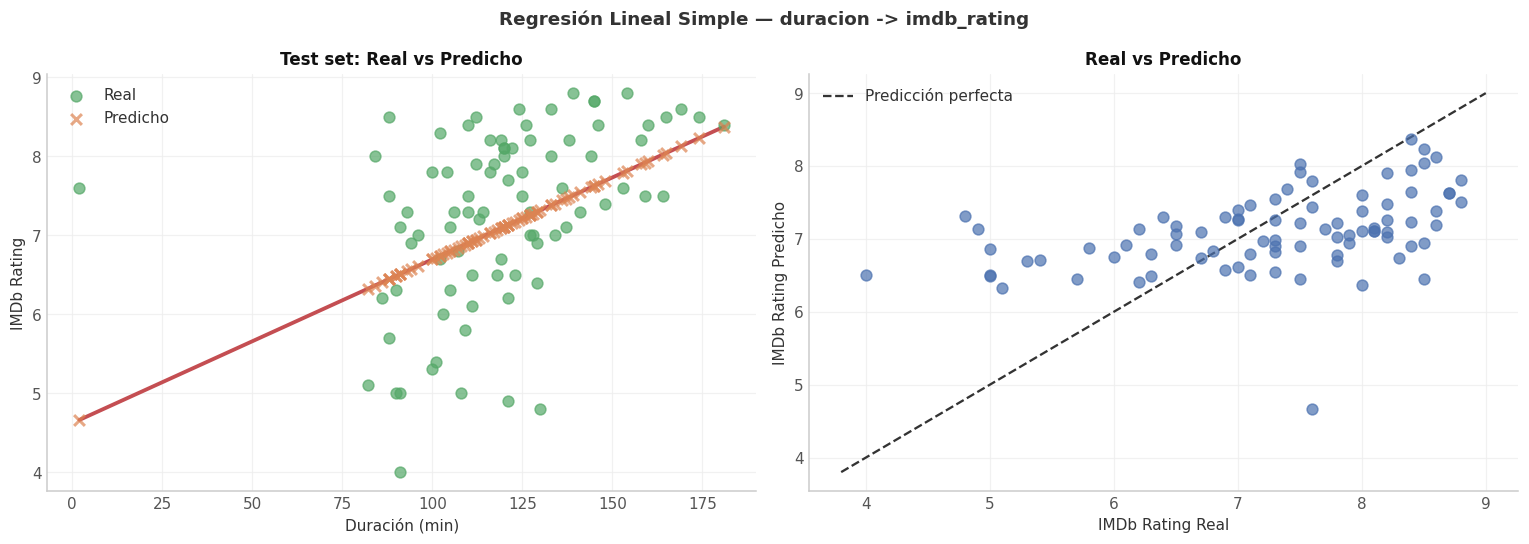

In [15]:
# ── CELDA 12: Gráfico regresión simple ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión Lineal Simple — duracion -> imdb_rating',
             fontsize=12, fontweight='bold')

axes[0].scatter(X_test_s.flatten(), y_test_s,
                color=C2, alpha=0.7, s=50, label='Real', zorder=3)
axes[0].scatter(X_test_s.flatten(), y_pred_simple,
                color=C3, alpha=0.7, s=50, marker='x', linewidths=2,
                label='Predicho', zorder=3)
x_line = np.linspace(X_test_s.min(), X_test_s.max(), 100)
axes[0].plot(x_line, B0_s + B1_s * x_line, color=C4, linewidth=2.5)
axes[0].set_xlabel('Duración (min)')
axes[0].set_ylabel('IMDb Rating')
axes[0].set_title('Test set: Real vs Predicho')
axes[0].legend()

lims = [min(y_test_s.min(), y_pred_simple.min()) - 0.2,
        max(y_test_s.max(), y_pred_simple.max()) + 0.2]
axes[1].scatter(y_test_s, y_pred_simple, color=C1, alpha=0.7, s=50, zorder=3)
axes[1].plot(lims, lims, color='#333333', linewidth=1.5,
             linestyle='--', label='Predicción perfecta')
axes[1].set_xlabel('IMDb Rating Real')
axes[1].set_ylabel('IMDb Rating Predicho')
axes[1].set_title('Real vs Predicho')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '05_regresion_simple.png'),
            dpi=300, bbox_inches='tight')
plt.show()


In [16]:
# ── CELDA 13: Métricas modelo simple ─────────────────────────
r2_s   = r2_score(y_test_s, y_pred_simple)
mse_s  = mean_squared_error(y_test_s, y_pred_simple)
rmse_s = np.sqrt(mse_s)
mae_s  = mean_absolute_error(y_test_s, y_pred_simple)
cv_scores_s = cross_val_score(
    LinearRegression(), X_s, y_s,
    cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')

print('=' * 56)
print('    METRICAS — REGRESION LINEAL SIMPLE')
print('    Feature: duracion')
print('=' * 56)
print(f'  R2   (test set)              : {r2_s:.4f}  ({r2_s*100:.2f}%)')
print(f'  R2   (CV 5-fold, media)      : {cv_scores_s.mean():.4f}  +/- {cv_scores_s.std():.4f}')
print(f'  MSE  (error cuadratico med)  : {mse_s:.4f}')
print(f'  RMSE (raiz del MSE)          : {rmse_s:.4f}')
print(f'  MAE  (error absoluto medio)  : {mae_s:.4f}')
print('=' * 56)


    METRICAS — REGRESION LINEAL SIMPLE
    Feature: duracion
  R2   (test set)              : 0.1531  (15.31%)
  R2   (CV 5-fold, media)      : 0.2173  +/- 0.0405
  MSE  (error cuadratico med)  : 1.0423
  RMSE (raiz del MSE)          : 1.0209
  MAE  (error absoluto medio)  : 0.8288


In [17]:
# ── CELDA 14: OLS statsmodels — regresion simple ─────────────
X_ols = sm.add_constant(df_simple['duracion'])
modelo_ols_simple = sm.OLS(df_simple['imdb_rating'], X_ols).fit()
print(modelo_ols_simple.summary())


                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     128.3
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.89e-26
Time:                        14:32:39   Log-Likelihood:                -618.65
No. Observations:                 422   AIC:                             1241.
Df Residuals:                     420   BIC:                             1249.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6948      0.218     21.574      0.0

## Modelo Multiple — Opcion A
### Features: `rec_por_min_log + anio + generos` (sin duracion)

Se elimina `duracion` para romper la dependencia con `rec_por_min_log`.  
VIF maximo: **~119 -> < 2**.

```
y_hat = B0 + B1*rec_por_min_log + B2*anio + B3*es_war + ... + error
```


In [18]:
# ── CELDA 15: Opcion A — fit + metricas ──────────────────────
df_A = df.dropna(subset=['rec_por_min_log', 'imdb_rating', 'anio']).copy()
print(f"Filas para Opcion A: {len(df_A)}")

features_A = ['rec_por_min_log', 'anio'] + top_generos

X_A = df_A[features_A].values
y_A = df_A['imdb_rating'].values
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42)

modelo_A = LinearRegression()
modelo_A.fit(X_train_A, y_train_A)
y_pred_A = modelo_A.predict(X_test_A)

r2_A   = r2_score(y_test_A, y_pred_A)
mse_A  = mean_squared_error(y_test_A, y_pred_A)
rmse_A = np.sqrt(mse_A)
mae_A  = mean_absolute_error(y_test_A, y_pred_A)
cv_A   = cross_val_score(LinearRegression(), X_A, y_A,
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='r2')

print('=' * 58)
print('  METRICAS — OPCION A  (rec_por_min_log + anio + generos)')
print('=' * 58)
print(f'  R2   (test set)          : {r2_A:.4f}  ({r2_A*100:.2f}%)')
print(f'  R2   (CV 5-fold)         : {cv_A.mean():.4f}  +/- {cv_A.std():.4f}')
print(f'  RMSE                     : {rmse_A:.4f}')
print(f'  MAE                      : {mae_A:.4f}')
print('=' * 58)
print('\nCoeficientes:')
for name, coef in zip(features_A, modelo_A.coef_):
    print(f'  {name:<22}  {coef:+.6f}')
print(f'  {"intercept":<22}  {modelo_A.intercept_:+.6f}')


Filas para Opcion A: 394
  METRICAS — OPCION A  (rec_por_min_log + anio + generos)
  R2   (test set)          : 0.1460  (14.60%)
  R2   (CV 5-fold)         : 0.2472  +/- 0.0851
  RMSE                     : 0.7582
  MAE                      : 0.6071

Coeficientes:
  rec_por_min_log         +0.290595
  anio                    -0.028643
  es_drama                +1.225432
  es_war                  +0.409363
  es_biography            +0.170064
  es_crime                +0.156090
  es_western              +0.745221
  intercept               +62.033700


In [19]:
# ── CELDA 16: OLS + VIF Opcion A ─────────────────────────────
X_ols_A = sm.add_constant(df_A[features_A])
modelo_ols_A = sm.OLS(df_A['imdb_rating'], X_ols_A).fit()
print(modelo_ols_A.summary())

print('\n── VIF Opcion A ──')
X_vif_A = df_A[features_A].values
for i, col in enumerate(features_A):
    vif  = variance_inflation_factor(X_vif_A, i)
    flag = 'OK' if vif < 5 else ('ADVERTENCIA' if vif < 10 else 'ERROR Severo')
    print(f'  {col:<22}  VIF = {vif:.3f}   {flag}')


                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     24.44
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.52e-27
Time:                        14:32:50   Log-Likelihood:                -558.94
No. Observations:                 394   AIC:                             1134.
Df Residuals:                     386   BIC:                             1166.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              60.8484      8.549     

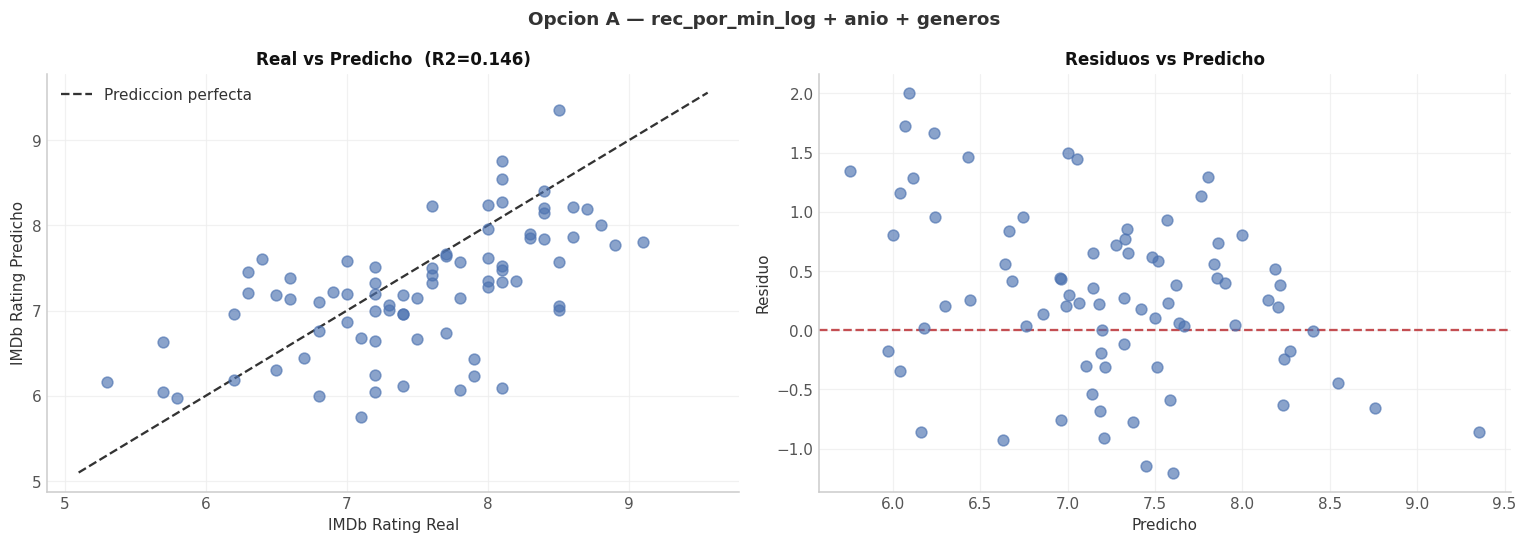

In [20]:
# ── CELDA 17: Graficos Opcion A ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Opcion A — rec_por_min_log + anio + generos', fontsize=12, fontweight='bold')

resid_A = y_test_A - y_pred_A
lims_A  = [min(y_test_A.min(), y_pred_A.min()) - 0.2,
           max(y_test_A.max(), y_pred_A.max()) + 0.2]

axes[0].scatter(y_test_A, y_pred_A, color=C1, alpha=0.65, s=50, zorder=3)
axes[0].plot(lims_A, lims_A, color='#333333', linewidth=1.5,
             linestyle='--', label='Prediccion perfecta')
axes[0].set_xlabel('IMDb Rating Real')
axes[0].set_ylabel('IMDb Rating Predicho')
axes[0].set_title(f'Real vs Predicho  (R2={r2_A:.3f})')
axes[0].legend()

axes[1].scatter(y_pred_A, resid_A, color=C1, alpha=0.65, s=50, zorder=3)
axes[1].axhline(0, color=C4, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predicho')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '06_modelo_opcion_A.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Modelo Multiple — Opcion C (mejor modelo)
### Features: `duracion + anio + generos` (sin recaudacion)

`duracion` tiene la correlacion mas alta (r ~ 0.28).  
Funciona con el **100% de las peliculas**, sin multicolinealidad (VIF < 2).

```
y_hat = B0 + B1*duracion + B2*anio + B3*es_war + B4*es_biography + ... + error
```


In [21]:
# ── CELDA 18: Opcion C — fit + metricas ──────────────────────
df_C = df.dropna(subset=['imdb_rating', 'duracion', 'anio']).copy()
print(f"Filas para Opcion C: {len(df_C)}  (todas las peliculas)")

features_C = ['duracion', 'anio'] + top_generos

X_C = df_C[features_C].values
y_C = df_C['imdb_rating'].values
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42)

modelo_C = LinearRegression()
modelo_C.fit(X_train_C, y_train_C)
y_pred_C = modelo_C.predict(X_test_C)

r2_C   = r2_score(y_test_C, y_pred_C)
mse_C  = mean_squared_error(y_test_C, y_pred_C)
rmse_C = np.sqrt(mse_C)
mae_C  = mean_absolute_error(y_test_C, y_pred_C)
cv_C   = cross_val_score(LinearRegression(), X_C, y_C,
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='r2')

print('=' * 56)
print('  METRICAS — OPCION C  (duracion + anio + generos)')
print('=' * 56)
print(f'  R2   (test set)          : {r2_C:.4f}  ({r2_C*100:.2f}%)')
print(f'  R2   (CV 5-fold)         : {cv_C.mean():.4f}  +/- {cv_C.std():.4f}')
print(f'  RMSE                     : {rmse_C:.4f}')
print(f'  MAE                      : {mae_C:.4f}')
print('=' * 56)
print('\nCoeficientes:')
for name, coef in zip(features_C, modelo_C.coef_):
    print(f'  {name:<22}  {coef:+.6f}')
print(f'  {"intercept":<22}  {modelo_C.intercept_:+.6f}')


Filas para Opcion C: 422  (todas las peliculas)
  METRICAS — OPCION C  (duracion + anio + generos)
  R2   (test set)          : 0.2164  (21.64%)
  R2   (CV 5-fold)         : 0.3161  +/- 0.0503
  RMSE                     : 0.9821
  MAE                      : 0.7455

Coeficientes:
  duracion                +0.013495
  anio                    -0.018098
  es_drama                +0.859947
  es_war                  +0.265389
  es_biography            +0.046417
  es_crime                +0.075582
  es_western              +0.257008
  intercept               +41.173481


In [22]:
# ── CELDA 19: OLS + VIF Opcion C ─────────────────────────────
X_ols_C = sm.add_constant(df_C[features_C])
modelo_ols_C = sm.OLS(df_C['imdb_rating'], X_ols_C).fit()
print(modelo_ols_C.summary())

print('\n── VIF Opcion C ──')
X_vif_C = df_C[features_C].values
for i, col in enumerate(features_C):
    vif  = variance_inflation_factor(X_vif_C, i)
    flag = 'OK' if vif < 5 else ('ADVERTENCIA' if vif < 10 else 'ERROR Severo')
    print(f'  {col:<22}  VIF = {vif:.3f}   {flag}')


                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     31.74
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.35e-35
Time:                        14:33:09   Log-Likelihood:                -584.25
No. Observations:                 422   AIC:                             1184.
Df Residuals:                     414   BIC:                             1217.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           42.6039      7.248      5.878   

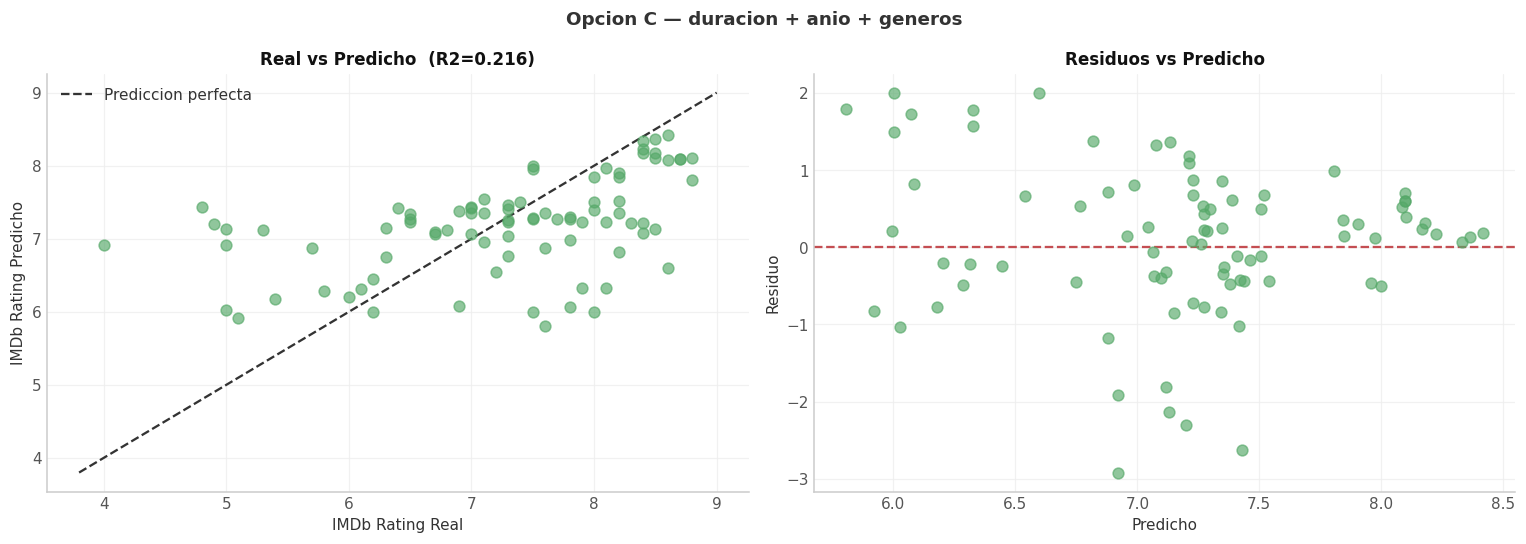

In [23]:
# ── CELDA 20: Graficos Opcion C ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Opcion C — duracion + anio + generos', fontsize=12, fontweight='bold')

resid_C = y_test_C - y_pred_C
lims_C  = [min(y_test_C.min(), y_pred_C.min()) - 0.2,
           max(y_test_C.max(), y_pred_C.max()) + 0.2]

axes[0].scatter(y_test_C, y_pred_C, color=C2, alpha=0.65, s=50, zorder=3)
axes[0].plot(lims_C, lims_C, color='#333333', linewidth=1.5,
             linestyle='--', label='Prediccion perfecta')
axes[0].set_xlabel('IMDb Rating Real')
axes[0].set_ylabel('IMDb Rating Predicho')
axes[0].set_title(f'Real vs Predicho  (R2={r2_C:.3f})')
axes[0].legend()

axes[1].scatter(y_pred_C, resid_C, color=C2, alpha=0.65, s=50, zorder=3)
axes[1].axhline(0, color=C4, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predicho')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '07_modelo_opcion_C.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Fase 6: Comparacion visual A vs C

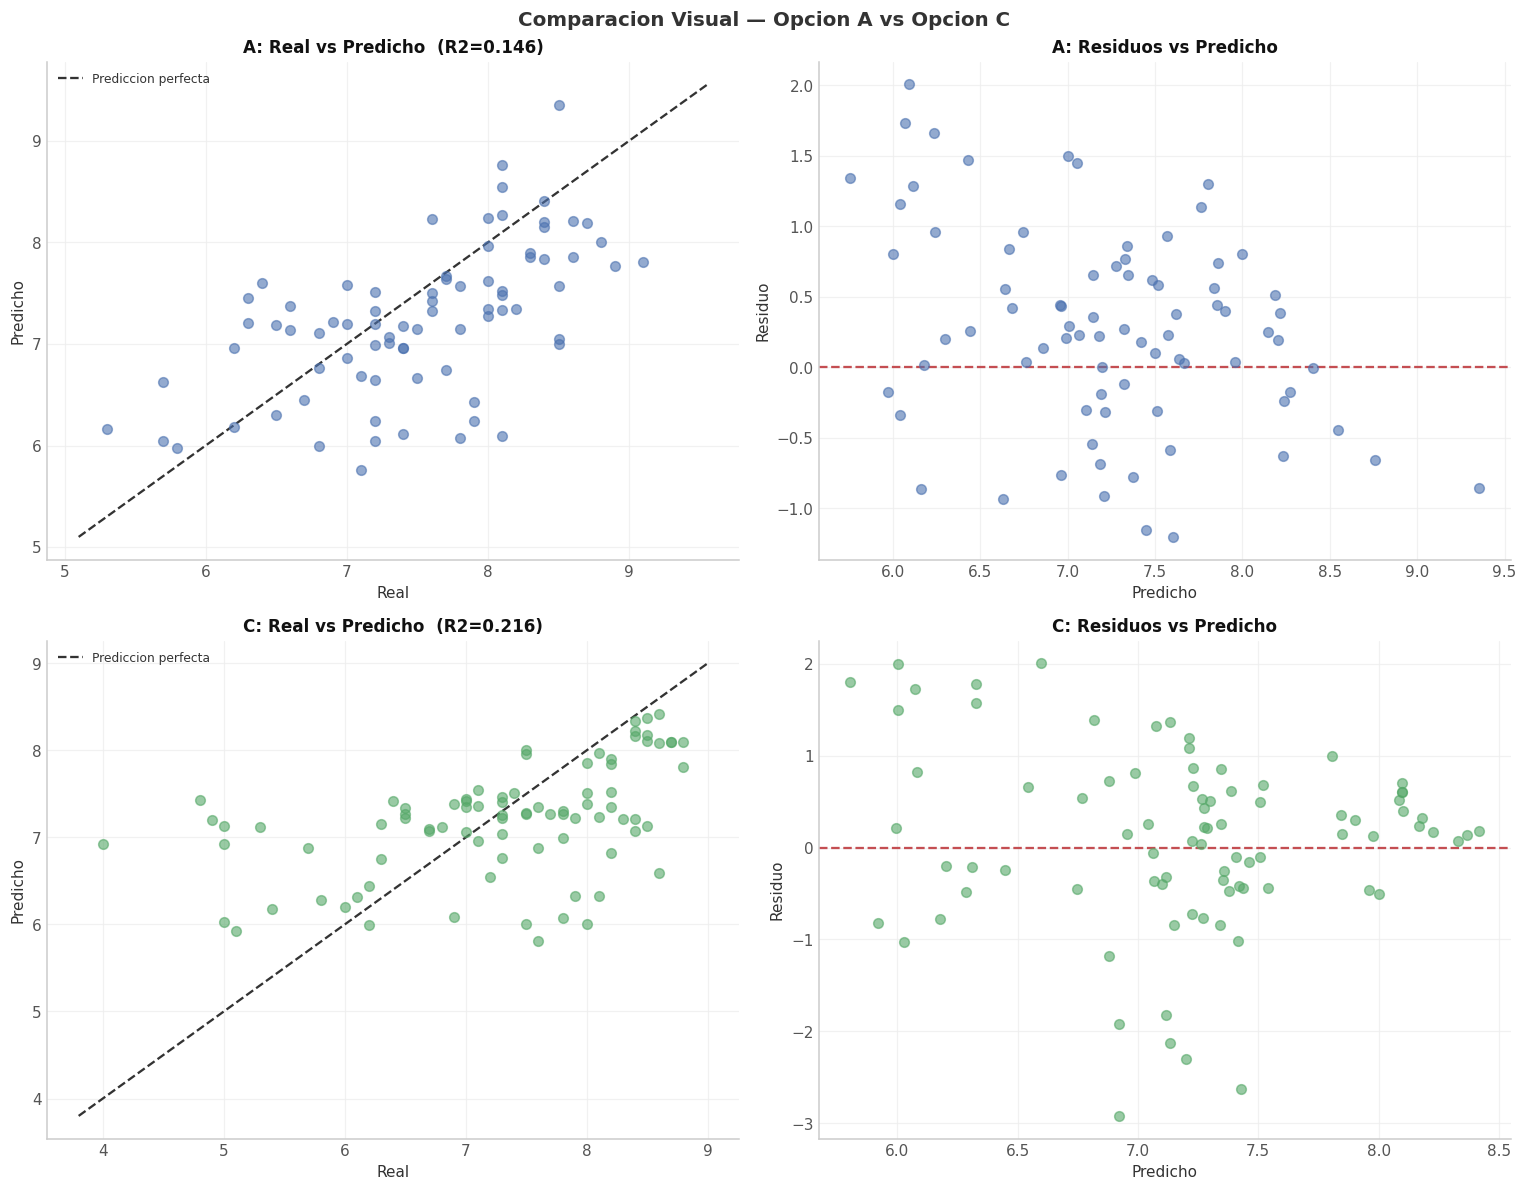

In [24]:
# ── CELDA 21: Panel comparativo A vs C ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Comparacion Visual — Opcion A vs Opcion C', fontsize=13, fontweight='bold')

def plot_pred(ax, y_real, y_pred, color, label):
    r2 = r2_score(y_real, y_pred)
    lims = [min(y_real.min(), y_pred.min()) - 0.2,
            max(y_real.max(), y_pred.max()) + 0.2]
    ax.scatter(y_real, y_pred, color=color, alpha=0.6, s=40, zorder=3)
    ax.plot(lims, lims, '#333333', linewidth=1.5, linestyle='--', label='Prediccion perfecta')
    ax.set_title(f'{label}  (R2={r2:.3f})')
    ax.set_xlabel('Real'); ax.set_ylabel('Predicho')
    ax.legend(fontsize=8)

def plot_resid(ax, y_pred, resid, color, label):
    ax.scatter(y_pred, resid, color=color, alpha=0.6, s=40, zorder=3)
    ax.axhline(0, color=C4, linewidth=1.5, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Residuo')

plot_pred (axes[0,0], y_test_A, y_pred_A, C1, 'A: Real vs Predicho')
plot_resid(axes[0,1], y_pred_A, y_test_A - y_pred_A, C1, 'A: Residuos vs Predicho')
plot_pred (axes[1,0], y_test_C, y_pred_C, C2, 'C: Real vs Predicho')
plot_resid(axes[1,1], y_pred_C, y_test_C - y_pred_C, C2, 'C: Residuos vs Predicho')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '08_comparacion_modelos.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Fase 7: Tabla comparativa — todos los modelos

In [25]:
# ── CELDA 22: Modelo Original (con VIF severo) para comparar ──
features_orig = ['rec_por_min_log', 'duracion', 'anio'] + top_generos
df_orig = df.dropna(subset=['rec_por_min_log', 'imdb_rating', 'duracion', 'anio']).copy()

X_orig = df_orig[features_orig].values
y_orig = df_orig['imdb_rating'].values
X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42)

modelo_orig = LinearRegression().fit(X_tr_o, y_tr_o)
y_pred_orig = modelo_orig.predict(X_te_o)

r2_orig   = r2_score(y_te_o, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_te_o, y_pred_orig))
mae_orig  = mean_absolute_error(y_te_o, y_pred_orig)
cv_orig   = cross_val_score(LinearRegression(), X_orig, y_orig,
                             cv=KFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='r2')

print(f"Modelo Original -> R2={r2_orig:.4f}  CV={cv_orig.mean():.4f}  RMSE={rmse_orig:.4f}")


Modelo Original -> R2=0.2250  CV=0.3407  RMSE=0.7223


           Modelo                             Variables   n  R2_test  R2_CV   RMSE    MAE VIF_max
Simple (duracion)                              duracion 422   0.1531 0.2173 1.0209 0.8288     N/A
Multiple Original rec_por_min_log+duracion+anio+generos 394   0.2250 0.3407 0.7223 0.5692    ~119
         Opcion A          rec_por_min_log+anio+generos 394   0.1460 0.2472 0.7582 0.6071      <2
         Opcion C                 duracion+anio+generos 422   0.2164 0.3161 0.9821 0.7455      <2

Opcion C: mejor R2, menor error, VIF limpio, 100% de los datos.


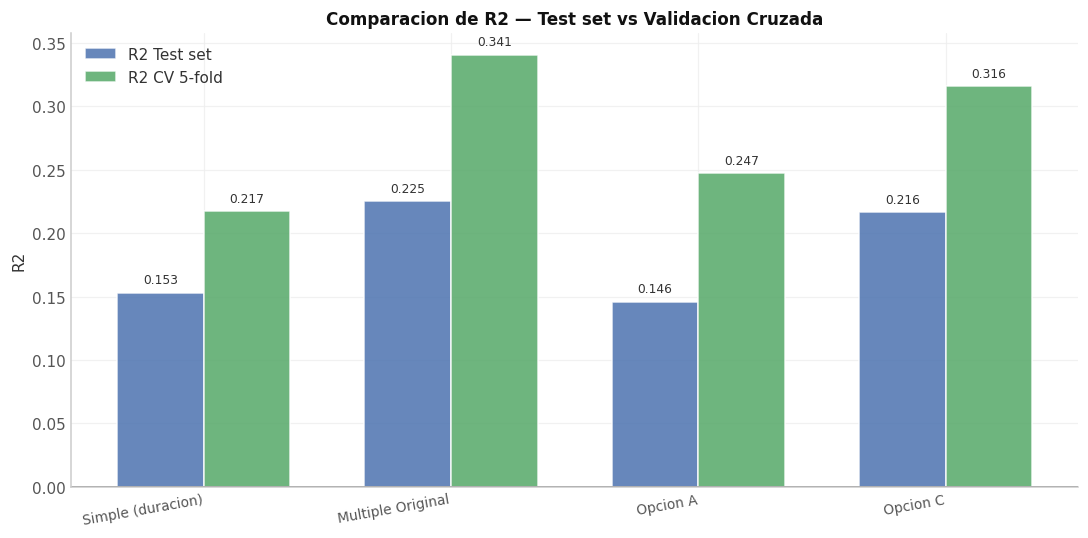

In [26]:
# ── CELDA 23: Tabla comparativa + grafico barras R2 ──────────
results = pd.DataFrame({
    'Modelo':      ['Simple (duracion)', 'Multiple Original', 'Opcion A', 'Opcion C'],
    'Variables':   ['duracion',
                    'rec_por_min_log+duracion+anio+generos',
                    'rec_por_min_log+anio+generos',
                    'duracion+anio+generos'],
    'n':           [len(df_simple), len(df_orig), len(df_A), len(df_C)],
    'R2_test':     [round(r2_s,4),    round(r2_orig,4), round(r2_A,4), round(r2_C,4)],
    'R2_CV':       [round(cv_scores_s.mean(),4), round(cv_orig.mean(),4),
                    round(cv_A.mean(),4),         round(cv_C.mean(),4)],
    'RMSE':        [round(rmse_s,4),  round(rmse_orig,4), round(rmse_A,4), round(rmse_C,4)],
    'MAE':         [round(mae_s,4),   round(mae_orig,4),  round(mae_A,4),  round(mae_C,4)],
    'VIF_max':     ['N/A', '~119', '<2', '<2'],
})
print(results.to_string(index=False))
print("\nOpcion C: mejor R2, menor error, VIF limpio, 100% de los datos.")

fig, ax = plt.subplots(figsize=(10, 5))
modelos  = results['Modelo'].tolist()
r2_vals  = results['R2_test'].tolist()
cv_vals  = results['R2_CV'].tolist()
x = np.arange(len(modelos))
w = 0.35

bars1 = ax.bar(x - w/2, r2_vals, w, label='R2 Test set',    color=C1, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, cv_vals, w, label='R2 CV 5-fold',   color=C2, alpha=0.85, edgecolor='white')
ax.axhline(0, color='#333333', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=10, ha='right', fontsize=9)
ax.set_ylabel('R2')
ax.set_title('Comparacion de R2 — Test set vs Validacion Cruzada', fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '09_comparacion_r2.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Fase 8: Diagnosticos de supuestos — Opcion C (mejor modelo)

In [27]:
# ── CELDA 24: Shapiro-Wilk + Breusch-Pagan ───────────────────
residuos_C = y_test_C - y_pred_C

stat_sw, pval_sw = stats.shapiro(residuos_C)
print('── Test Shapiro-Wilk (normalidad de residuos) ──')
print(f'   Estadistico : {stat_sw:.6f}')
print(f'   p-value     : {pval_sw:.6f}')
print(f'   {"OK No se rechaza normalidad (p > 0.05)" if pval_sw > 0.05 else "ALERTA: Residuos no normales (p < 0.05)"}')

X_bp = sm.add_constant(pd.DataFrame(X_test_C, columns=features_C))
bp_lm, bp_pval, _, _ = het_breuschpagan(residuos_C, X_bp)
print('\n── Test Breusch-Pagan (homocedasticidad) ──')
print(f'   LM stat  : {bp_lm:.6f}')
print(f'   p-value  : {bp_pval:.6f}')
print(f'   {"OK Homocedasticidad (p > 0.05)" if bp_pval > 0.05 else "ALERTA: Heterocedasticidad (p < 0.05)"}')


── Test Shapiro-Wilk (normalidad de residuos) ──
   Estadistico : 0.961737
   p-value     : 0.012788
   ALERTA: Residuos no normales (p < 0.05)

── Test Breusch-Pagan (homocedasticidad) ──
   LM stat  : 11.219842
   p-value  : 0.129313
   OK Homocedasticidad (p > 0.05)


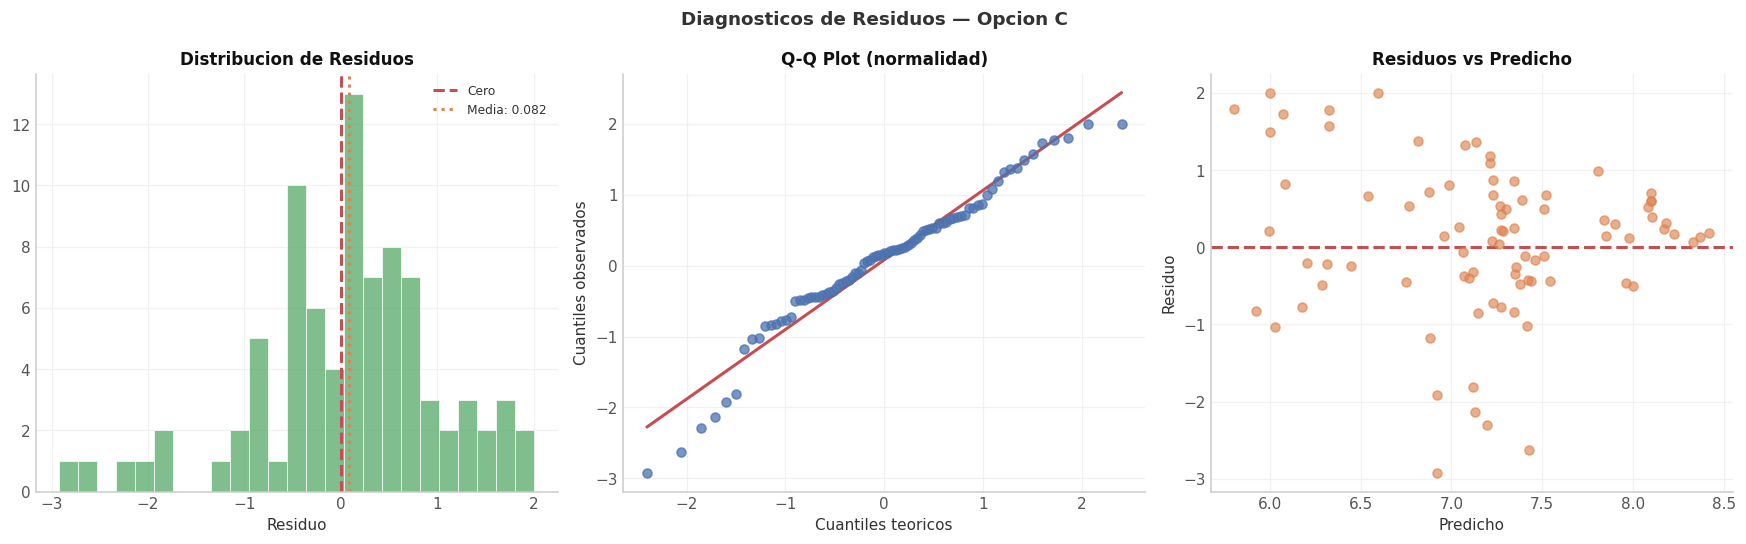

In [28]:
# ── CELDA 25: Graficos de diagnosticos ───────────────────────
residuos_C = y_test_C - y_pred_C

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Diagnosticos de Residuos — Opcion C', fontsize=12, fontweight='bold')

axes[0].hist(residuos_C, bins=25, color=C2, alpha=0.75, edgecolor='white', linewidth=0.6)
axes[0].axvline(0, color=C4, linestyle='--', linewidth=2, label='Cero')
axes[0].axvline(residuos_C.mean(), color=C3, linestyle=':', linewidth=2,
                label=f'Media: {residuos_C.mean():.3f}')
axes[0].set_title('Distribucion de Residuos')
axes[0].set_xlabel('Residuo')
axes[0].legend(fontsize=8)

(osm, osr), (slope, intercept, _) = stats.probplot(residuos_C, dist='norm')
axes[1].scatter(osm, osr, color=C1, alpha=0.75, s=35, zorder=3)
axes[1].plot(osm, slope * np.array(osm) + intercept, color=C4, linewidth=2)
axes[1].set_title('Q-Q Plot (normalidad)')
axes[1].set_xlabel('Cuantiles teoricos')
axes[1].set_ylabel('Cuantiles observados')

axes[2].scatter(y_pred_C, residuos_C, color=C3, alpha=0.65, s=35, zorder=3)
axes[2].axhline(0, color=C4, linewidth=2, linestyle='--')
axes[2].set_title('Residuos vs Predicho')
axes[2].set_xlabel('Predicho')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '10_diagnosticos_residuos.png'),
            dpi=300, bbox_inches='tight')
plt.show()


Importancia de coeficientes — Opcion C (estandarizados):
     Feature  Coef_Original  Coef_Estandarizado
  es_western       0.257008            0.036853
    es_crime       0.075582            0.040461
es_biography       0.046417            0.046731
      es_war       0.265389            0.073279
        anio      -0.018098           -0.258357
    es_drama       0.859947            0.336987
    duracion       0.013495            0.400066


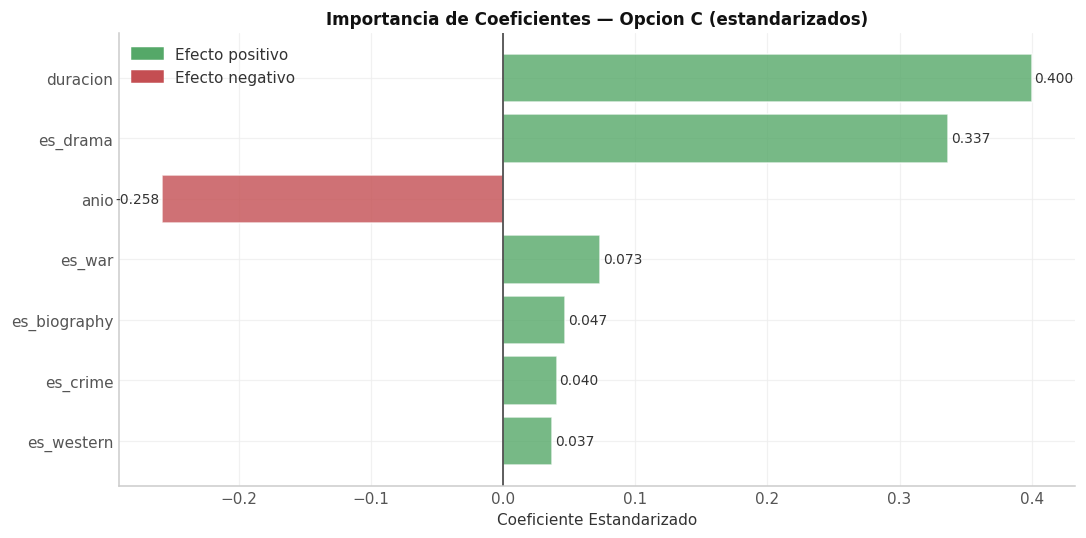

In [29]:
# ── CELDA 26: Importancia de coeficientes estandarizados ──────
scaler       = StandardScaler()
X_C_scaled   = scaler.fit_transform(df_C[features_C].values)
modelo_C_std = LinearRegression().fit(X_C_scaled, y_C)

coef_df = pd.DataFrame({
    'Feature':            features_C,
    'Coef_Original':      modelo_C.coef_,
    'Coef_Estandarizado': modelo_C_std.coef_,
}).sort_values('Coef_Estandarizado', key=abs, ascending=True)

print('Importancia de coeficientes — Opcion C (estandarizados):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [C2 if c > 0 else C4 for c in coef_df['Coef_Estandarizado']]
ax.barh(coef_df['Feature'], coef_df['Coef_Estandarizado'],
        color=bar_colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='#333333', linewidth=1)
for i, val in enumerate(coef_df['Coef_Estandarizado']):
    ax.text(val + (0.002 if val >= 0 else -0.002), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Importancia de Coeficientes — Opcion C (estandarizados)', fontweight='bold')
ax.set_xlabel('Coeficiente Estandarizado')
ax.legend(handles=[
    mpatches.Patch(color=C2, label='Efecto positivo'),
    mpatches.Patch(color=C4, label='Efecto negativo'),
])
plt.tight_layout()
plt.savefig(os.path.join(RUTA_GRAFICAS, '11_importancia_coeficientes.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## Predictor interactivo — Opcion A y C

In [30]:
# ── CELDA 27: Predictor doble (Opcion A + C) ─────────────────
# Modifica estos valores para predecir cualquier pelicula
nueva_pelicula = {
    'titulo':      'Mi Pelicula de Prueba',
    'duracion':    148,
    'anio':        2022,
    'recaudacion': 800_000_000,
    'generos':     ['es_drama', 'es_crime'],
}

gen_vec = {g: (1 if g in nueva_pelicula['generos'] else 0) for g in top_generos}

# Opcion A (necesita recaudacion)
rec_log_val = np.log10(nueva_pelicula['recaudacion'] / nueva_pelicula['duracion'])
X_A_new = np.array([[rec_log_val, nueva_pelicula['anio'],
                      *[gen_vec[g] for g in top_generos]]])
pred_A = float(np.clip(modelo_A.predict(X_A_new)[0], 1.0, 10.0))

# Opcion C (sin recaudacion)
X_C_new = np.array([[nueva_pelicula['duracion'], nueva_pelicula['anio'],
                      *[gen_vec[g] for g in top_generos]]])
pred_C = float(np.clip(modelo_C.predict(X_C_new)[0], 1.0, 10.0))

print('=' * 55)
print(f"  Pelicula         : {nueva_pelicula['titulo']}")
print(f"  Duracion         : {nueva_pelicula['duracion']} min")
print(f"  Anio             : {nueva_pelicula['anio']}")
print(f"  Recaudacion      : ${nueva_pelicula['recaudacion']:,.0f}")
print(f"  Generos          : {nueva_pelicula['generos']}")
print('=' * 55)
print(f"  IMDb predicho  A Opcion A : {pred_A:.2f} / 10")
print(f"  IMDb predicho  C Opcion C : {pred_C:.2f} / 10")
print('=' * 55)


  Pelicula         : Mi Pelicula de Prueba
  Duracion         : 148 min
  Anio             : 2022
  Recaudacion      : $800,000,000
  Generos          : ['es_drama', 'es_crime']
  IMDb predicho  A Opcion A : 7.46 / 10
  IMDb predicho  C Opcion C : 7.51 / 10


## Resumen Final

In [31]:
# ── CELDA 28: Resumen ejecutivo ──────────────────────────────
print(f"""
+----------------------------------------------------------+
|       RESUMEN EJECUTIVO — REGRESION PELICULAS v2         |
+----------------------------------------------------------+
|  Dataset      : {len(df)} peliculas unicas
+----------------------------------------------------------+
|  MODELO           R2_test   R2_CV    RMSE    VIF_max
|  --------------------------------------------------------
|  Simple           {r2_s:.4f}    {cv_scores_s.mean():.4f}   {rmse_s:.4f}   N/A
|  Original         {r2_orig:.4f}    {cv_orig.mean():.4f}   {rmse_orig:.4f}   ~119
|  Opcion A         {r2_A:.4f}    {cv_A.mean():.4f}   {rmse_A:.4f}   <2
|  Opcion C (*)     {r2_C:.4f}    {cv_C.mean():.4f}   {rmse_C:.4f}   <2
+----------------------------------------------------------+
|  (*) GANADOR: Opcion C  (duracion + anio + generos)      |
|  > Mayor R2, menor RMSE/MAE                              |
|  > Sin multicolinealidad (VIF < 2)                       |
|  > Funciona con el 100% de las peliculas                 |
+----------------------------------------------------------+
""")



+----------------------------------------------------------+
|       RESUMEN EJECUTIVO — REGRESION PELICULAS v2         |
+----------------------------------------------------------+
|  Dataset      : 422 peliculas unicas
+----------------------------------------------------------+
|  MODELO           R2_test   R2_CV    RMSE    VIF_max
|  --------------------------------------------------------
|  Simple           0.1531    0.2173   1.0209   N/A
|  Original         0.2250    0.3407   0.7223   ~119
|  Opcion A         0.1460    0.2472   0.7582   <2
|  Opcion C (*)     0.2164    0.3161   0.9821   <2
+----------------------------------------------------------+
|  (*) GANADOR: Opcion C  (duracion + anio + generos)      |
|  > Mayor R2, menor RMSE/MAE                              |
|  > Sin multicolinealidad (VIF < 2)                       |
|  > Funciona con el 100% de las peliculas                 |
+----------------------------------------------------------+

